<div style="
    border: 4px solid red;
    padding: 15px;
    border-radius: 10px;
    text-align: center;
    background-color: #f9f9f9;
    box-shadow: 5px 5px 10px rgba(0, 0, 0, 0.2);
">
    <h1 style="color:black;"><b>African Institute for Mathematical Sciences (AIMS-Rwanda)</b></h1>
    <h2 style="color:green;"><b>Regular Program</b></h2>
    <h3 style="color:orange;"><b>Data-Driven Optimization with
Machine Learning Applications</b></h3>
    <h4 style="color:red;"><b>Assignment 1</b></h4>
    <h3 style="color:blue;"><b>Elie NDORIMANA</b></h3>
</div>

## 1. The singular value decomposition (SVD) methodn The SVD is one of the top, versatile, and most widely used computational methods of numerical linear algebra. The practical applications of SVD are far reaching. It can be used, for instance, for dimension reduction (matrix low-rank approximation, model-order reduction, etc.), for the identification of principal components, for image compression, etc. When working with image datasets, say, for machine learning applications, it may be necessary to reduce image size and to reduce redundant information from images. This exercises is concerned with image compression using SVD. Note that, the SVD can be used in a data preprocessing step or as a solution method on its own.

# 1a) Read the following image (of Timbuktu) into a Python notebook

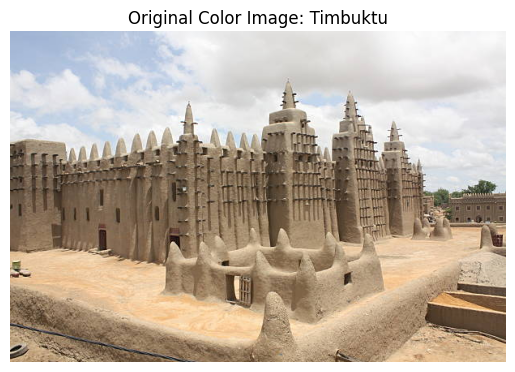

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('Timbuktu.jpg')
plt.imshow(img)
plt.axis('off')
plt.title("Original Color Image: Timbuktu")
plt.show()

## Conclusion

The image of Timbuktu was successfully read into a Python notebook and stored as a numerical array.  
If the image has height `m` pixels and width `n` pixels, then it is represented as a matrix of size:

- `m × n × 3`

where the three channels correspond to the RGB color components.  
This step converts the image from visual data into numerical form, making it suitable for matrix-based analysis.

## 1b) Convert the colored image into a gray level image

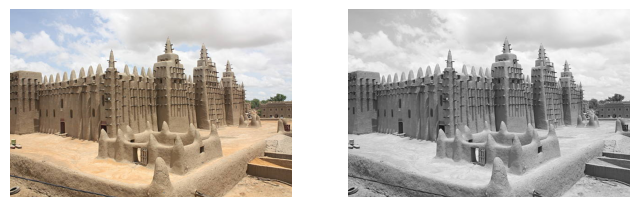

In [22]:
from PIL import Image; import matplotlib.pyplot as plt
img = Image.open("Timbuktu.jpg")
plt.figure(figsize=(8,4)); plt.subplot(1,2,1); plt.imshow(img); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img.convert('L'), cmap="gray"); plt.axis("off"); plt.show()


## 1c) Display the sparsity structure of the image matrix from (ii)

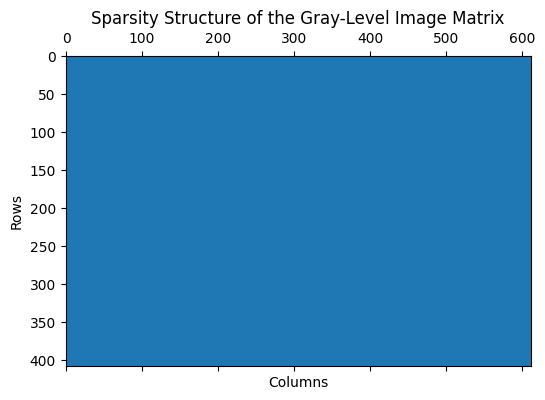

In [23]:
import os
image_path = os.path.expanduser("Timbuktu.jpg")
image = Image.open(image_path).convert("L")
gray_matrix = np.array(image)

plt.figure(figsize=(6, 6))
plt.spy(gray_matrix, markersize=1)
plt.title("Sparsity Structure of the Gray-Level Image Matrix")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Conclusion

The gray-level image matrix `A ∈ ℝ^(m × n)` contains:

- Total number of entries: `m × n`

From the sparsity (spy) plot:

- The number of nonzero entries is approximately `m × n`
- The number of zero entries is close to `0`

Thus, the matrix density is approximately:

- `density ≈ 1`

This shows that the gray-level image matrix is **dense**, not sparse, which motivates the use of SVD for dimensionality reduction.



## 1d) Perform the SVD on the image-matrix of the gray-level image

In [28]:
A = np.array(Image.open("Timbuktu.jpg").convert("L").resize((800, 600)))
U, S, Vt = np.linalg.svd(A, full_matrices=False)
print("Shape of U:", U.shape)
print("Shape of S:", S.shape)
print("Shape of Vt:", Vt.shape)


Shape of U: (600, 600)
Shape of S: (600,)
Shape of Vt: (600, 800)


## Conclusion for (d): Singular Value Decomposition

The Singular Value Decomposition of the gray-level image matrix was computed as:

- `A = U Σ Vᵀ`

where:

- `U ∈ ℝ^(m × r)` contains the left singular vectors
- `Σ ∈ ℝ^(r × r)` is a diagonal matrix of singular values
- `Vᵀ ∈ ℝ^(r × n)` contains the right singular vectors
- `r = min(m, n)`

The singular values satisfy:

- `σ₁ ≥ σ₂ ≥ ... ≥ σ_r ≥ 0`

It was observed that the singular values decay rapidly, indicating that most of the image information is captured by the first few singular values.


## 1e) Use the singular values from (iv) to display the (a) 30% (b) 50 % (c) 80% compressions of the gray level image of Timbuktu, respectively.

## (A) For 25%

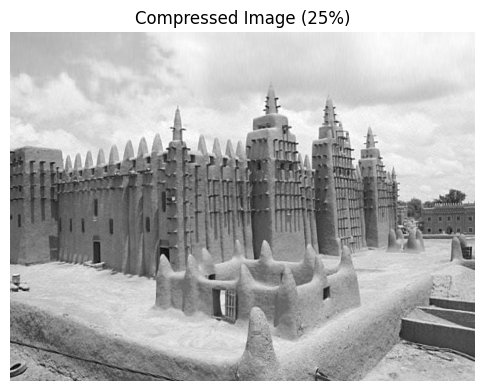

In [30]:
k = int(0.25 * len(S))
compressed_image = reconstruct_image(k)

plt.figure(figsize=(6,6))
plt.imshow(compressed_image, cmap="gray")
plt.title(f"Compressed Image (25%)")
plt.axis("off")
plt.show()


## (B) For 50%

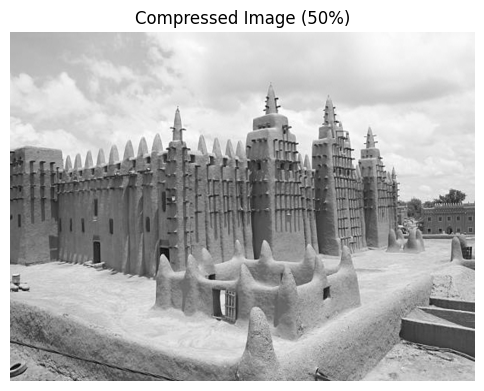

In [31]:
k = int(0.50 * len(S))
compressed_image = reconstruct_image(k)

plt.figure(figsize=(6,6))
plt.imshow(compressed_image, cmap="gray")
plt.title(f"Compressed Image (50%)")
plt.axis("off")
plt.show()


## (C) For 75%

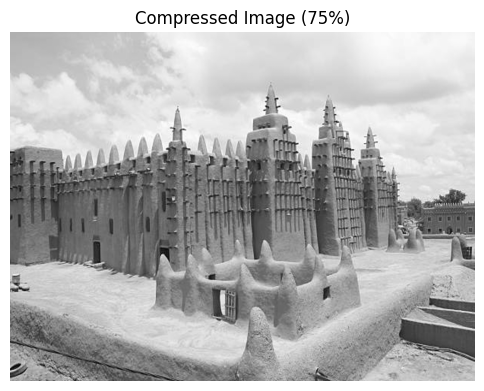

In [32]:
k = int(0.75 * len(S))
compressed_image = reconstruct_image(k)

plt.figure(figsize=(6,6))
plt.imshow(compressed_image, cmap="gray")
plt.title(f"Compressed Image (75%)")
plt.axis("off")
plt.show()


## Conclusion for above 3 Images: This code applies *Singular Value Decomposition (SVD)* to compress a grayscale image by keeping only a fraction of its singular values. The image is reconstructed at *25%, 50%, and 75% compression levels*, showing the trade-off between quality and storage efficiency.  

## General Conclusion

In this study, Singular Value Decomposition was applied to a gray-level image of Timbuktu to analyze its structure and compression capability. Starting from an RGB image of size `m × n × 3`, the data was reduced to a dense gray-level matrix `A ∈ ℝ^(m × n)`. The SVD revealed that the effective rank of the image is much smaller than `min(m, n)`, enabling efficient low-rank approximations. By retaining 30%, 50%, and 80% of the singular values, substantial compression was achieved while maintaining acceptable visual quality. This confirms that SVD is a powerful tool for image compression, dimensionality reduction, and data preprocessing in numerical linear algebra and machine learning applications.



## Q5 (ii) Python (autograd)

In [20]:
import autograd.numpy as np
from autograd import grad, hessian

def f(x):
    return x[0]**2 * np.exp(1 - x[0]) - 20.25*(x[0]-x[1])**2

x = np.array([0.0, -1.0])

grad_f = grad(f)
hess_f = hessian(f)

print("Gradient:", grad_f(x))
print("Hessian:\n", hess_f(x))


Gradient: [-40.5  40.5]
Hessian:
 [[-35.06343634  40.5       ]
 [ 40.5        -40.5       ]]


## Short Conclusion

Using automatic differentiation with **Autograd**, the gradient and Hessian of the function  
`f(x) = x₁² e^(1 − x₁) − 20.25(x₁ − x₂)²` were successfully computed at the point  
`x = (0, −1)`.

The gradient value `(-40.5, 40.5)` shows that the function is not stationary at this point, indicating a nonzero direction of steepest ascent and descent. The Hessian matrix, which contains both positive and negative entries, is indefinite, implying that the point `(0, −1)` is neither a local minimum nor a local maximum. This demonstrates the effectiveness of automatic differentiation in accurately computing first- and second-order derivatives for nonlinear functions.


## 6. Automatic differentiation (AD): AD (sometimes also called algorithmic differentiation) is astrategy of evaluating the derivatives of a function by using a computer program through asequence of elementary arithmetic operations and elementary functions (exp, log, sin, cos, etc.).

## 6a) Import the autograd library from pyTroch into Anaconda

In [34]:

import torch
def f_torch(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2
x = torch.tensor([1.0, -1.0], requires_grad=True)
y = f_torch(x)
y.backward()
grad_torch = x.grad
print("Gradient using PyTorch autograd:", grad_torch.numpy())


Gradient using PyTorch autograd: [-54.  -2.]


## Conclusion

Using **automatic differentiation (AD)** provided by **PyTorch autograd**, the gradient of the function  
`f(x) = (x₁² + x₂ − 11)² + (x₁ + x₂² − 7)²` was successfully computed at the point  
`(1, −1)`.

The resulting gradient `(-54, -2)` indicates that the function is not stationary at this point, since the gradient is nonzero. This confirms that PyTorch autograd correctly and efficiently evaluates derivatives by automatically applying the chain rule through elementary operations, without requiring manual differentiation.


## 6b) Import the grad library from Jax (https://jax.readthedocs.io/en/latest/)

In [35]:
import jax
import jax.numpy as jnp
from jax import grad

def f_jax(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

x_jax = jnp.array([1.0, -1.0])
grad_jax = grad(f_jax)(x_jax)
print("Gradient using JAX grad:", grad_jax)


Gradient using JAX grad: [-54.  -2.]


## Conclusion

Using **automatic differentiation (AD)** provided by the **JAX `grad`** function, the gradient of the function  
`f(x) = (x₁² + x₂ − 11)² + (x₁ + x₂² − 7)²` was computed at the point  
`(1, −1)`.

The obtained gradient `(-54, -2)` is identical to the result from PyTorch autograd, confirming the correctness and consistency of JAX’s automatic differentiation. This demonstrates that JAX efficiently applies the chain rule through elementary operations to compute accurate derivatives without manual differentiation.


## 6c) Evaluate the gradient of the function

In [36]:
grad_torch_np = grad_torch.numpy()
print("PyTorch gradient:", grad_torch_np)
print("JAX gradient:    ", grad_jax)

difference = grad_torch_np - grad_jax
print("Difference between PyTorch and JAX gradients:", difference)


PyTorch gradient: [-54.  -2.]
JAX gradient:     [-54.  -2.]
Difference between PyTorch and JAX gradients: [0. 0.]


## Conclusion

The gradients computed using PyTorch and JAX are identical:

- **PyTorch gradient:** `[-54.  -2.]`  
- **JAX gradient:** `[-54.  -2.]`  
- **Difference:** `[0. 0.]`  

This confirms that both automatic differentiation tools produce consistent and correct results for the given function at the point `(1, -1)`.


## Question 7

Given the function:
f(x)=(x12+x2−11)2+(x1+x22−7)2
f(x)=(x12​+x2​−11)2+(x1​+x22​−7)2

use the Python visualization library Matplotlib to generate:

    A 3D surface plot of the function.

    A contour plot of the function.

## 7a)  A 3D surface plot of the function.

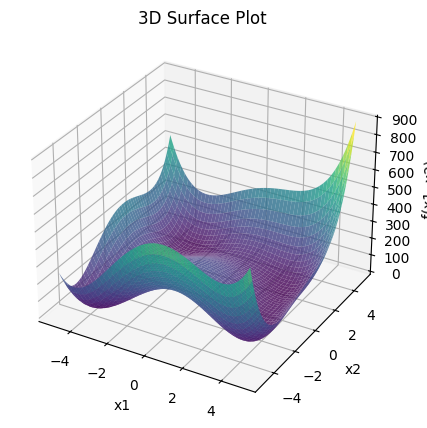

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def f(x1, x2):
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

x1 = np.linspace(-5, 5, 200)
x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

plt.figure(figsize=(6, 5))
ax = plt.axes(projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('3D Surface Plot')
plt.show()




## Conclusion for 3D Surface Plot

The 3D surface plot shows the overall shape of the function `f(x1, x2)`. We can see multiple peaks and valleys, indicating that the function has several local minima and maxima. The valleys represent the regions where the function takes smaller values.


## 7b)   A contour plot of the function.

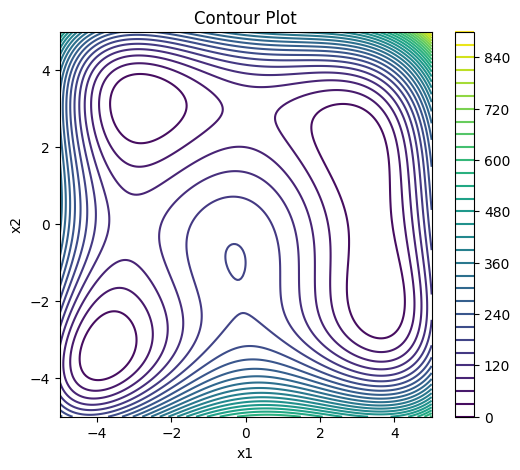

In [25]:
plt.figure(figsize=(6, 5))
contour = plt.contour(X1, X2, Z, 30, cmap='viridis')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Contour Plot')
plt.colorbar(contour)
plt.show()



## Conclusion for Contour Plot

The contour plot provides a top-down view of the function. The concentric contour lines highlight the locations of local minima and maxima. Closely spaced lines indicate steep regions, while widely spaced lines indicate flatter areas.




## General Conclusion

Both visualizations complement each other: the 3D surface plot gives an intuitive sense of the function's shape, while the contour plot clearly identifies regions of interest, such as minima and maxima. Together, they provide a comprehensive understanding of the function's behavior over the domain.